In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from keras.optimizers import Adam
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("cleaned_dataset_taiwan_2months.csv")
df = df.sort_values('date')
df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
125913,2024-07-01 00:00:00,Xindian,New Taipei City,36.0,Good,0.9,0.16,11.9,25.0,10.0,4.7,5.5,0.8,4
125851,2024-07-01 00:00:00,Banqiao,New Taipei City,22.0,Good,0.5,0.34,8.4,21.0,6.0,12.6,14.9,2.2,6
125852,2024-07-01 00:00:00,Xinzhuang,New Taipei City,28.0,Good,0.5,0.29,10.9,20.0,8.0,9.0,9.3,0.3,7
125853,2024-07-01 00:00:00,Cailiao,New Taipei City,33.0,Good,0.9,0.39,6.8,17.0,9.0,16.7,18.3,1.6,8
125854,2024-07-01 00:00:00,Linkou,New Taipei City,19.0,Good,1.2,0.17,8.0,10.0,8.0,8.7,10.3,1.5,9


In [4]:
features=['so2','co','o3','pm2.5','pm10','no2','nox','no']

status=['aqi']
X=df[features]
y=df[status]  


In [5]:
unique_dates = df['date'].unique()
split_idx = int(len(unique_dates) * 0.8)
train_dates = unique_dates[:split_idx]

df_train = df[df['date'].isin(train_dates)].copy()
df_test = df[~df['date'].isin(train_dates)].copy()

In [6]:
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

def create_sequences_by_station(dataframe, feature_cols, window_size=24):
    X_seq, y_seq = [], []
    # Group by station name to keep timelines fully isolated
    for station, group in dataframe.groupby('sitename'):
        group_sorted = group.sort_values('date')
        group_features = group_sorted[feature_cols].values
        group_targets = group_sorted['aqi'].values
        
        if len(group_sorted) > window_size:
            for i in range(len(group_sorted) - window_size):
                X_seq.append(group_features[i : (i + window_size)])
                y_seq.append(group_targets[i + window_size])
                
    return np.array(X_seq), np.array(y_seq)

# Build valid 3D shapes representing (Samples, 24 Hours, 8 Features)
X_train_seq, y_train_seq = create_sequences_by_station(df_train, features, window_size=24)
X_test_seq, y_test_seq = create_sequences_by_station(df_test, features, window_size=24)

print("Clean Train Sequence Shape:", X_train_seq.shape)
print("Clean Test Sequence Shape:", X_test_seq.shape)

Clean Train Sequence Shape: (98590, 24, 8)
Clean Test Sequence Shape: (23244, 24, 8)


In [7]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(24, 8)), 
    
    # First GRU layer 
    layers.GRU(128, return_sequences=True),
    layers.BatchNormalization(), # Added for stability based on your previous design
    layers.Dropout(0.4),
    
    # Second GRU layer
    layers.GRU(64, return_sequences=True),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Second GRU layer
    layers.GRU(32),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(1, activation='linear')
])

In [8]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mae',
    metrics=['mae','mse'

    ]
)

In [ ]:
# callback for saving checkpoint and early stop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_rf_regressor).keras', monitor='val_loss', save_best_only=True),
    reduce_lr
]

In [10]:
model.fit(
X_train_seq, y_train_seq,
epochs=100,
batch_size=256,
shuffle=True,
validation_split=0.2,
verbose=1,
callbacks=my_callbacks
)#training nn

Epoch 1/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 47s 131ms/step - loss: 29.3008 - mae: 29.3008 - mse: 1009.9062 - val_loss: 28.8502 - val_mae: 28.8502 - val_mse: 983.2859 - learning_rate: 5.0000e-04
Epoch 2/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - loss: 25.1290 - mae: 25.1290 - mse: 777.3629 - val_loss: 22.7468 - val_mae: 22.7468 - val_mse: 617.5246 - learning_rate: 5.0000e-04
Epoch 3/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - loss: 17.2155 - mae: 17.2155 - mse: 391.7503 - val_loss: 13.1561 - val_mae: 13.1561 - val_mse: 220.1110 - learning_rate: 5.0000e-04
Epoch 4/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - loss: 7.5245 - mae: 7.5245 - mse: 102.8365 - val_loss: 7.5836 - val_mae: 7.5836 - val_mse: 74.8912 - learning_rate: 5.0000e-04
Epoch 5/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 43s 139ms/step - loss: 3.9459 - mae: 3.9459 - mse: 32.2261 - val_loss: 5.7549 - val_mae: 5.7549 - val_mse: 47.7862 - learning_rate: 5.0000e-04
Epoch 6/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - lo

In [11]:
#Generate pseudo-labels from the fully trained GRU model
print("Generating teacher pseudo-labels...")
nn_pseudo_labels = model.predict(X_train_seq)
y_pseudo_train = nn_pseudo_labels.flatten()

#Flatten properly aligned 3D sequences into a 2D format for the Random Forest
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_flat_sequences = X_test_seq.reshape(X_test_seq.shape[0], -1)

#Train the student Regressor with proper initialization constraints
print("Training Optimized Student Random Forest...")
rf_distilled = RandomForestRegressor(
    n_estimators=50,       # Streamlines tree generation
    max_depth=12,          # Limits float split depth to run efficiently
    n_jobs=-1,             # Runs processing in parallel across all CPU cores
    random_state=20
)
rf_distilled.fit(X_train_flat, y_pseudo_train)

#Predict and evaluate performance metrics
y_pred_rf = rf_distilled.predict(X_test_flat_sequences)

print("\n--- Corrected Distilled Random Forest Regression Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_seq, y_pred_rf):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_seq, y_pred_rf):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_seq, y_pred_rf)):.4f}")
print(f"R-squared (R2) Variance Score: {r2_score(y_test_seq, y_pred_rf):.4f}")

Generating teacher pseudo-labels...
3081/3081 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step
Training Optimized Student Random Forest...

--- Corrected Distilled Random Forest Regression Performance ---
Mean Absolute Error (MAE): 2.4542
Mean Squared Error (MSE): 17.5737
Root Mean Squared Error (RMSE): 4.1921
R-squared (R2) Variance Score: 0.9225


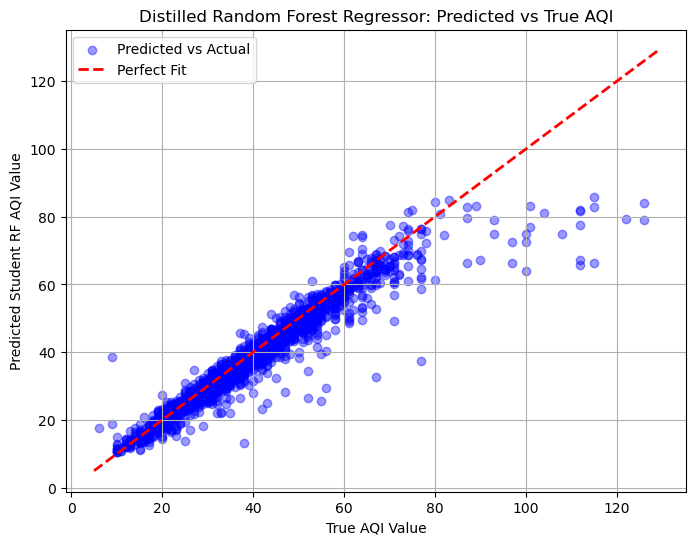

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_seq[:2000], y_pred_rf[:2000], alpha=0.4, color='b', label='Predicted vs Actual')

# Plot accurate perfect diagonal trendline boundary
perfect_line = [min(y_test_seq), max(y_test_seq)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('True AQI Value')
plt.ylabel('Predicted Student RF AQI Value')
plt.title('Distilled Random Forest Regressor: Predicted vs True AQI')
plt.legend()
plt.grid(True)
plt.savefig('regression_fit_perf.png')

In [13]:
import joblib

# 1. Save the Trained Student Random Forest Regressor
# Using compress=3 reduces file size significantly on your disk
joblib.dump(rf_distilled, 'distilled_random_forest_regressor.pkl', compress=3)
print("✅ Student Random Forest Model successfully saved as 'distilled_random_forest_regressor.pkl'")

# 2. Save the Standard Scaler (Crucial for transforming new deployment inputs correctly)
joblib.dump(scaler, 'aqi_scaler.pkl')
print("✅ Feature Scaler successfully saved as 'aqi_scaler.pkl'")

# 3. Save the Trained Teacher GRU Deep Learning Model
# Keras models should be saved in native .keras format
model.save('teacher_gru_regressor.keras')
print("✅ Teacher GRU Deep Learning Model successfully saved as 'teacher_gru_regressor.keras'")

✅ Student Random Forest Model successfully saved as 'distilled_random_forest_regressor.pkl'
✅ Feature Scaler successfully saved as 'aqi_scaler.pkl'
✅ Teacher GRU Deep Learning Model successfully saved as 'teacher_gru_regressor.keras'
